In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy import sparse, linalg
from scipy.io import loadmat,savemat
from math import factorial

from numpy.random import randint
import sklearn as sk
from sklearn.mixture import GaussianMixture # jaxxx??? # Hyakkk
from sklearn.decomposition import SparsePCA
# from scipy.io import loadmat
import matplotlib as mpl
from matplotlib.colors import ListedColormap
import matplotlib.colors as colors

# Seaborn colormap
import seaborn as sns
import colorcet as cc
sns_list = sns.color_palette(cc.glasbey,n_colors=20).as_hex()
sns_list.pop(4)

# sns_list.insert(0, '#ffffff')  # Insert white at zero position
sns_cmap = ListedColormap(sns_list)
cm = sns_cmap

sns_list_balance_models = sns_list.copy()

sns_list_balance_models.insert(0, '#ffffff')  # Insert white at zero position
sns_list_balance_models.pop(1)
sns_cmap_balance_models = ListedColormap(sns_list_balance_models)

cm_balance_models = sns_cmap_balance_models
  
mpl_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
            '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
            '#bcbd22', '#17becf']

# Plot Spanwise Velocity

In [9]:
def apply_midline_symmetry(array):
    # assuming it's the full 194 x 193 array
    arr_top = array[97:, :]
    arr_topFlipped = np.flip(arr_top, axis = 0)
    arr_bottom = (arr_topFlipped + array[:97, :])/2

    arr_right = arr_bottom[:, 97:]
    arr_left = np.zeros_like(arr_bottom[:, 0:97])

    arr_rightFlipped = np.flip(arr_right, axis = 1)

    arr_left[:,:-1] = (arr_bottom[:, 0:96] - arr_rightFlipped)/2
    arr_left[:,-1] = arr_bottom[:,96]

    return arr_left

def apply_centerline_symmetry(array):
    # assuming it's the full 194 x 193 array
    arr_top = array[97:, :]
    arr_topFlipped = np.flip(arr_top, axis = 0)
    arr_bottom = (array[:97, :] - arr_topFlipped)/2

    arr_right = arr_bottom[:, 97:]
    arr_left = np.zeros_like(arr_bottom[:, 0:97])

    arr_rightFlipped = np.flip(arr_right, axis = 1)

    arr_left[:,:-1] = (arr_bottom[:, 0:96] + arr_rightFlipped)/2
    arr_left[:,-1] = arr_bottom[:,96]

    return arr_left

def apply_diagonal_symmetry(array):
    # assuming it's the full 194 x 193 array
    arr_top = array[97:, :]
    arr_topFlipped = np.flip(arr_top, axis = 0)
    arr_bottom = (array[:97, :] - arr_topFlipped)/2

    arr_right = arr_bottom[:, 97:]
    arr_left = np.zeros_like(arr_bottom[:, 0:97])

    arr_rightFlipped = np.flip(arr_right, axis = 1)

    arr_left[:,:-1] = (arr_bottom[:, 0:96] - arr_rightFlipped)/2
    arr_left[:,-1] = arr_bottom[:,96]

    return arr_left

def apply_symmetry(array):
    # assuming it's the full 194 x 193 array
    arr_top = array[97:, :]
    arr_topFlipped = np.flip(arr_top, axis = 0)
    arr_bottom = (arr_topFlipped + array[:97, :])/2

    arr_right = arr_bottom[:, 97:]
    arr_left = np.zeros_like(arr_bottom[:, 0:97])

    arr_rightFlipped = np.flip(arr_right, axis = 1)

    arr_left[:,:-1] = (arr_bottom[:, 0:96] + arr_rightFlipped)/2
    arr_left[:,-1] = arr_bottom[:,96]

    return arr_left

In [10]:
raw_data = loadmat('data/duct180.mat',squeeze_me=True, struct_as_record=False)['duct180']
nu = 1/2500 # 1/Re_b
x = raw_data.xx
y = raw_data.yy

xx,yy = np.meshgrid(x,y)

U = raw_data.time.U
V = raw_data.time.V
W = raw_data.time.W
uw = raw_data.time.uw
vw = raw_data.time.vw

''' Apply symmetries of the duct! '''
# Take bottom left quad
xx_symm = xx[:97, :97]
yy_symm = yy[:97, :97]

U_symm = np.array(apply_midline_symmetry(U)) # U is only symmetric across the midline
V_symm = np.array(apply_centerline_symmetry(V)) # V is only symmetric across the centerline
W_symm = np.array(apply_symmetry(W)) # W is symmetric across all 4 quadrants

In [3]:
labels = [r'$T \frac{\partial \Omega_z}{\partial t}$', r'$N \frac{\partial \Omega_z}{\partial n}$',
            r'$\frac{\partial^2 \Omega_z}{\partial t^2}$', r'$\frac{\partial^2 \Omega_z}{\partial n^2}$', 
            #r'$\Omega_x\frac{\partial U}{\partial x}$', r'$\Omega_y\frac{\partial V}{\partial y}$',
            r'$(RS_{\hat{t}})$', r'$(RS_{\hat{n}})$']

In [13]:
V_symm.shape

(97, 97)

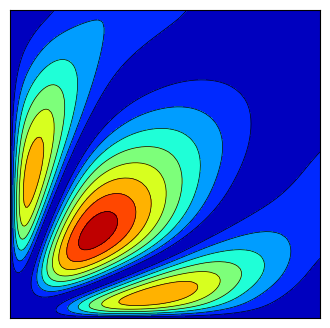

In [60]:
plt.figure(figsize = (4,4))
levels=9
# plt.pcolormesh(masked_x_coords_DNS_grid,masked_y_coords_DNS_grid,Omega_z,cmap='jet')
plt.contourf(xx_symm,yy_symm,np.abs(U_symm+V_symm),cmap='jet',levels=levels)
plt.contour(xx_symm,yy_symm,np.abs(U_symm+V_symm),levels=levels,colors=['k'], linestyles='solid',linewidths=0.5)
# plt.colorbar(boundaries=np.arange(0.5, nc+1.5), ticks=np.arange(0, nc+1))
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.savefig(f'VelocityDomain.png',bbox_inches='tight')
plt.show()
plt.close()